In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

import warnings
warnings.simplefilter("ignore")

data1 = pd.read_csv('D:\\cloneGitHubPj\\WZU-machine-learning-course\\code\\12-支持向量机\\data\\svmdata1.csv')
data1.head()

,X1,X2,y
0,1.9643,4.5957,1
1,2.2753,3.8589,1
2,2.9781,4.5651,1
3,2.9320,3.5519,1
4,3.5772,2.8560,1


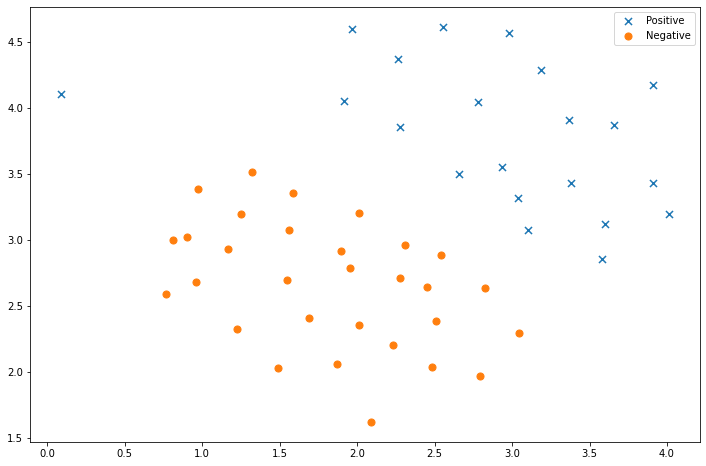

In [3]:
positive = data1[data1['y'].isin([1])]
negative = data1[data1['y'].isin([0])]
 
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(positive['X1'], positive['X2'], s=50, marker='x', label='Positive')
ax.scatter(negative['X1'], negative['X2'], s=50, marker='o', label='Negative')
ax.legend()
plt.show()

In [4]:
from sklearn import svm
svc = svm.LinearSVC(C=1, loss='hinge', max_iter=1000)
svc

LinearSVC(C=1, loss='hinge')

In [5]:
svc.fit(data1[['X1', 'X2']], data1['y'])
svc.score(data1[['X1', 'X2']], data1['y'])

0.9803921568627451

In [7]:
svc2 = svm.LinearSVC(C=100, loss='hinge', max_iter=1000)
svc2.fit(data1[['X1', 'X2']], data1['y'])
svc2.score(data1[['X1', 'X2']], data1['y'])

0.9411764705882353

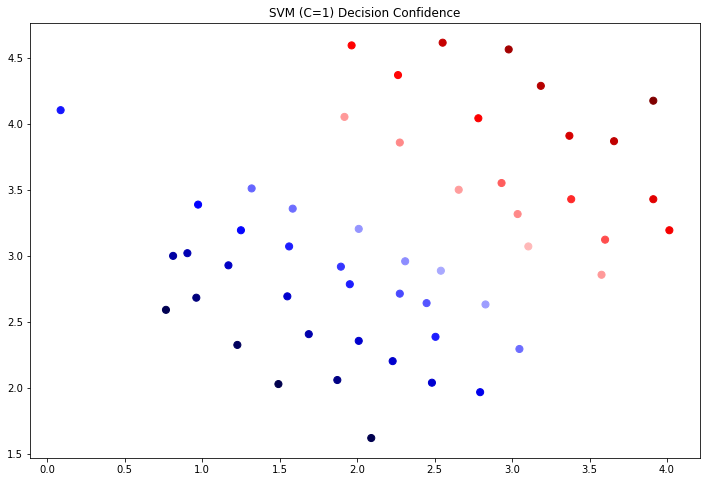

In [8]:
data1['SVM 1 Confidence'] = svc.decision_function(data1[['X1', 'X2']])
 
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(data1['X1'],
           data1['X2'],
           s=50,
           c=data1['SVM 1 Confidence'],
           cmap='seismic')
ax.set_title('SVM (C=1) Decision Confidence')
plt.show()

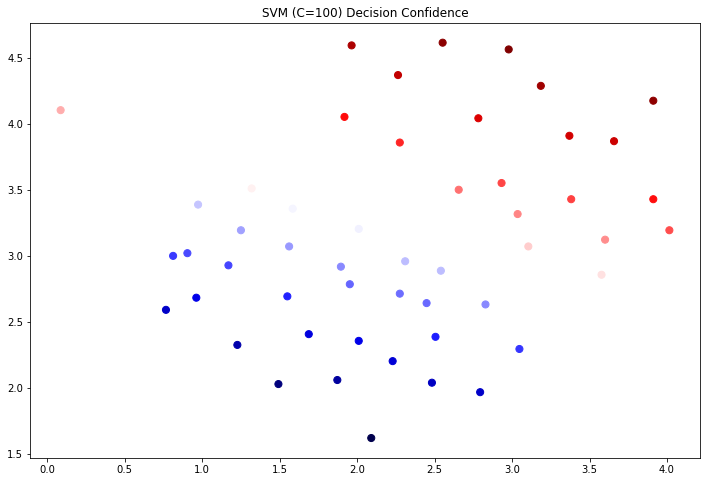

In [9]:
data1['SVM 2 Confidence'] = svc2.decision_function(data1[['X1', 'X2']])
 
fig, ax = plt.subplots(figsize=(12,8))
ax.scatter(data1['X1'], data1['X2'], s=50, c=data1['SVM 2 Confidence'], cmap='seismic')
ax.set_title('SVM (C=100) Decision Confidence')
plt.show()

In [10]:
def gaussian_kernel(x1, x2, sigma):
    return np.exp(-(np.sum((x1 - x2)**2) / (2 * (sigma**2))))

In [11]:
x1 = np.array([1.0, 2.0, 1.0])
x2 = np.array([0.0, 4.0, -1.0])
sigma = 2
 
gaussian_kernel(x1, x2, sigma)

0.32465246735834974

In [12]:
data2 = pd.read_csv('D:\\cloneGitHubPj\\WZU-machine-learning-course\\code\\12-支持向量机\\data\\svmdata2.csv')

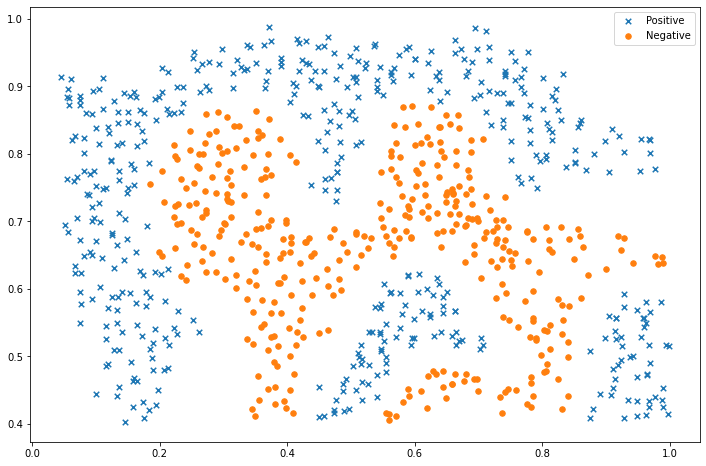

In [13]:
positive = data2[data2['y'].isin([1])]
negative = data2[data2['y'].isin([0])]
 
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(positive['X1'], positive['X2'], s=30, marker='x', label='Positive')
ax.scatter(negative['X1'], negative['X2'], s=30, marker='o', label='Negative')
ax.legend()
plt.show()

In [14]:
svc = svm.SVC(C=100, gamma=10, probability=True)
svc

SVC(C=100, gamma=10, probability=True)

In [15]:
svc.fit(data2[['X1', 'X2']], data2['y'])
svc.score(data2[['X1', 'X2']], data2['y'])

0.9698725376593279

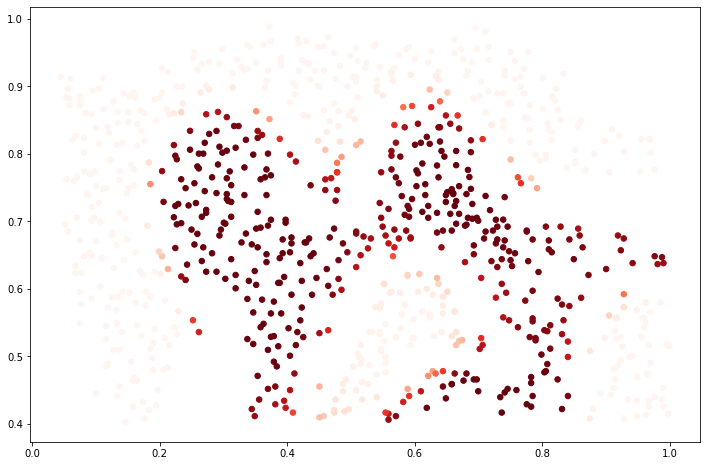

In [16]:
data2['Probability'] = svc.predict_proba(data2[['X1', 'X2']])[:, 0]
 
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(data2['X1'], data2['X2'], s=30, c=data2['Probability'], cmap='Reds')
plt.show()

In [17]:
data3=pd.read_csv('D:\\cloneGitHubPj\\WZU-machine-learning-course\\code\\12-支持向量机\\data\\svmdata3.csv')
data3val=pd.read_csv('D:\\cloneGitHubPj\\WZU-machine-learning-course\\code\\12-支持向量机\\data\\svmdata3val.csv')

In [18]:
X = data3[['X1','X2']]
Xval = data3val[['X1','X2']]
y = data3['y'].ravel()
yval = data3val['yval'].ravel()

In [19]:
C_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
gamma_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
 
best_score = 0
best_params = {'C': None, 'gamma': None}
 
for C in C_values:
    for gamma in gamma_values:
        svc = svm.SVC(C=C, gamma=gamma)
        svc.fit(X, y)
        score = svc.score(Xval, yval)
 
        if score > best_score:
            best_score = score
            best_params['C'] = C
            best_params['gamma'] = gamma
 
best_score, best_params

(0.965, {'C': 0.3, 'gamma': 100})

In [20]:
from sklearn.svm import SVC
from sklearn import datasets
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]
 
setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]
 
# SVM Classifier model
svm_clf = SVC(kernel="linear", C=float("inf"))
svm_clf.fit(X, y)

SVC(C=inf, kernel='linear')

In [21]:
# Bad models
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5 * x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

In [22]:
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
 
    # At the decision boundary, w0*x0 + w1*x1 + b = 0
    # => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]
 
    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
 
    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
    plt.plot(x0, decision_boundary, "k-", linewidth=2)
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)

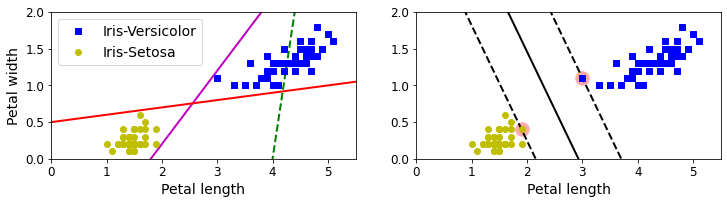

In [23]:
plt.figure(figsize=(12, 2.7))
 
plt.subplot(121)
plt.plot(x0, pred_1, "g--", linewidth=2)
plt.plot(x0, pred_2, "m-", linewidth=2)
plt.plot(x0, pred_3, "r-", linewidth=2)
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], "bs", label="Iris-Versicolor")
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], "yo", label="Iris-Setosa")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 5.5, 0, 2])
 
plt.subplot(122)
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], "bs")
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], "yo")
plt.xlabel("Petal length", fontsize=14)
plt.axis([0, 5.5, 0, 2])
 
plt.show()

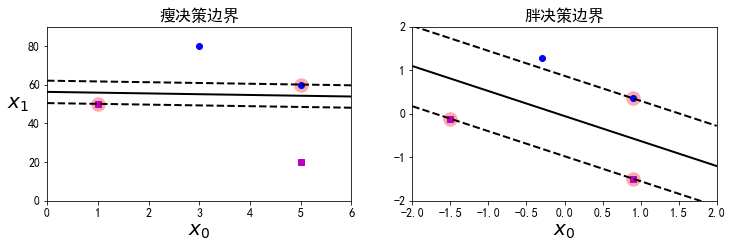

In [26]:
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus'] = False
Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64)
ys = np.array([0, 0, 1, 1])
svm_clf = SVC(kernel="linear", C=100)
svm_clf.fit(Xs, ys)
 
plt.figure(figsize=(12, 3.2))
plt.subplot(121)
plt.plot(Xs[:, 0][ys == 1], Xs[:, 1][ys == 1], "bo")
plt.plot(Xs[:, 0][ys == 0], Xs[:, 1][ys == 0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 6)
plt.xlabel("$x_0$", fontsize=20)
plt.ylabel("$x_1$  ", fontsize=20, rotation=0)
plt.title("瘦决策边界", fontsize=16)
plt.axis([0, 6, 0, 90])
 
from sklearn.preprocessing import StandardScaler
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xs)
svm_clf.fit(X_scaled, ys)
 
plt.subplot(122)
plt.plot(X_scaled[:, 0][ys == 1], X_scaled[:, 1][ys == 1], "bo")
plt.plot(X_scaled[:, 0][ys == 0], X_scaled[:, 1][ys == 0], "ms")
plot_svc_decision_boundary(svm_clf, -2, 2)
plt.xlabel("$x_0$", fontsize=20)
plt.title("胖决策边界", fontsize=16)
plt.axis([-2, 2, -2, 2])
plt.show()